<a href="https://colab.research.google.com/github/gerryfrank10/ComputerVision/blob/main/Computer_Vision_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Packing Items Using Computer Vision and Optimization

BOURNEMOUTH UNIVERSITY


### Necessary Steps Like Installing Dependencies and Libraries

We’ll begin by installing the libraries required for object detection (YOLO) and mathematical optimization (Pyomo). These tools are the pillars of our pipeline.

In [21]:
#Install ultralytics
!pip install ultralytics

# Install pyomo and dependecies
!apt-get install -y glpk-utils
!pip install pyomo
!pip install albumentations

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
glpk-utils is already the newest version (5.0-1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [22]:
# Importing the necessary libraries
import torchvision
import torch
from torchvision import transforms as T

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import patches, patheffects
import math
import pandas as pd
import numpy as np
import albumentations as A
from shutil import copyfile
from glob import glob
import time

# OpenCv and YOLO
import cv2
from ultralytics import YOLO

In [10]:
# Download the dataset
'''
This code depends if you cant find the dataset for any reason in the file then download this dataset.
'''
url = 'https://github.com/gerryfrank10/ComputerVision/raw/refs/heads/main/assignment/datasets/images.zip'
!wget {url}

--2025-05-13 19:46:29--  https://github.com/gerryfrank10/ComputerVision/raw/refs/heads/main/assignment/datasets/images.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/gerryfrank10/ComputerVision/refs/heads/main/assignment/datasets/images.zip [following]
--2025-05-13 19:46:29--  https://raw.githubusercontent.com/gerryfrank10/ComputerVision/refs/heads/main/assignment/datasets/images.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77935578 (74M) [application/zip]
Saving to: ‘images.zip’

images.zip          100%[===================>]  74.32M   337MB/s    in 0.2s    

2025-05-13 19:46:29 (33

In [11]:
!unzip images.zip

Archive:  images.zip
   creating: images/
  inflating: images/.DS_Store        
  inflating: __MACOSX/images/._.DS_Store  
  inflating: images/images6.jpg      
  inflating: __MACOSX/images/._images6.jpg  
  inflating: images/images7.jpg      
  inflating: __MACOSX/images/._images7.jpg  
  inflating: images/ruler8.jpg       
  inflating: __MACOSX/images/._ruler8.jpg  
  inflating: images/images5.jpg      
  inflating: __MACOSX/images/._images5.jpg  
  inflating: images/images4.jpg      
  inflating: __MACOSX/images/._images4.jpg  
  inflating: images/images1.jpg      
  inflating: __MACOSX/images/._images1.jpg  
  inflating: images/images3.jpg      
  inflating: __MACOSX/images/._images3.jpg  
  inflating: images/images2.jpg      
  inflating: __MACOSX/images/._images2.jpg  
  inflating: images/image10.jpeg     
  inflating: __MACOSX/images/._image10.jpeg  
  inflating: images/ruler2.jpg       
  inflating: __MACOSX/images/._ruler2.jpg  
  inflating: images/image8.jpeg      
  inflatin

In [41]:
# Important functions
def show_img(im, ax=None, figsize=(8,8), title=None):
    if not ax: _,ax = plt.subplots(1,1,figsize=figsize)
    if len(im.shape)==2: im = np.tile(im[:,:,None], 3)
    ax.imshow(im);
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    if title: ax.set_title(title)
    return ax
# Also important functions
def show_imgs(ims, rows=1, figsize=(16,8), title=[None]):
    title = title*len(ims) if len(title) == 1 else title
    _,ax = plt.subplots(rows, len(ims)//rows, figsize=figsize)
    [show_img(im,ax_,title=tit) for im,ax_,tit in zip(ims,ax.flatten(),title)]
    return ax
# Drawing multiple rectangles
def draw_rect(ax, xy, w, h):
    patch = ax.add_patch(patches.Rectangle(xy, w, h, fill=False, edgecolor='yellow', lw=2))
    patch.set_path_effects([patheffects.Stroke(linewidth=4, foreground='black'), patheffects.Normal()])
def visualize_detections(image, detections, score_key='score'):
    """
    Draws bounding boxes and labels on the given image using detection results.

    Parameters:
    - image: A NumPy image array (RGB).
    - detections: A list of dictionaries with keys 'bbox', 'label', and a confidence key.
    - score_key: The key used to access confidence score ('score' for Faster R-CNN, 'confidence' for YOLO).
    """
    image = cv2.imread(image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    for detection in detections:
      if(detection['bbox']):
        x1, y1, x2, y2 = detection['bbox']
        width = x2 - x1
        height = y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
      else:
        score = detection.get(score_key, 0)
        ax.text(x1, y1, f"{detection['label']} ({score:.2f})", color='r', fontsize=8)

    plt.axis('off')
    plt.show()

## Abstract

This section presents a comprehensive exploration of the problem of ourproblem our project which addresses efficientlyaddresses to : efficiently packing a set of items into a constrained container using a combination of computer vision and mathematical optimization techniques. By building from a detailed understanding of the task, and integrating feedback from academic advisors, this report section aims to establish a clear, logical progression from problem definition to algorithmic design. We present the use of different computer vision techniques to achieve measuring sizes of objects in an image, and different mathematical algorithms to pack the measured and detected items in a constrained container. The emphasis here is on demonstrating deep conceptual understanding before selecting and implementing specific solutions.

## Introduction

The efficient use of space is a universal logistical challenge. Whether in shipping containers, warehouse shelving, delivery vans, or even digital storage, the need to fit multiple entities into limited space optimally is always present. This packing problem becomes significantly more complex when items vary in shape and size. With the rapid advancement of artificial intelligence and computer vision technologies, the possibility of automating this process has gained considerable interest.
https://ieeexplore.ieee.org/abstract/document/9291401 highlights the use of Neural Network to solve Based Solver. These solvers aren’t state of the art, but it shows how different approaches can be implemented to solve knapsack problems. https://www.nature.com/articles/srep34851 also shows how humans solve complex problems of a discrete optimization problem like a knapsack, where the author points how the complexity of the problem is defined to computer science. We See this problem applicable in a variety of domains from filling the bucket in supermarkets, to warehouse and other complex problems.
Our project targets a specific variant of this challenge: using a top-down camera view to detect a set of items placed on a surface, and computing whether those items can fit into a specified container. If feasible, the system should also estimate determine an efficient arrangement. The potential impact of our solution is to support automation in environments such as e-commerce warehouses, moving logistics, or even industrial manufacturing setups.


##Problem Definition

Our problem can be broken down into two primary objectives:

* Feasibility Evaluation: Can the given set of detected items be arranged to fit within a designated container?
* Optimization: If yes, what is the best way to arrange them to minimize wasted space, reduce the number of containers, or improve another metric of interest?


We approach this through a layered strategy. First, we process visual data using computer vision to identify and extract item characteristics, primarily their two-dimensional dimensions (width and height). Then, we pass this information to an algorithm that attempts to virtually place the items into a container.


This packing challenge is closely related to variations of the ***knapsack and bin-packing problems*** in combinatorial optimization. The classic knapsack problem focuses on selecting items to maximize value within a weight constraint, and most versions consider 3d Taking3D—taking into account weight, height, and length. The 2D bin-packing problem, by contrast, focuses only on item dimensions and spatial arrangement.
In addition, existing solutions for these problems typically assign a value to each item being placed in the bin or knapsack. The goal is to choose the best combination of items to maximize total value. We’ve slightly changed the objective in our problem to focus on optimizing space.
What makes our approach different is that we don’t assign any value to the items, allitems—all items are treated equally. For our problem, we only care about whether the items fit and how efficiently we can arrange them. So instead of maximizing value, our goal is to minimize the space used within the container.

Project Scope and Feedback Integration Our academic supervisor advised that we begin with a simplified version of the problem and scale up over time.
* Initially, all items are considered rectangular, with edges aligned to the axes.
* Items are assumed to be correctly detected, with estimated perfect dimensional data.
* Only one container is considered in the first phase.
* Rotation is limited to 90 degree90-degree turns.

The motivation behind this simplification is two fold. Firstly, axis-aligned rectangles reduce computational complexity and help verify our early algorithms. Secondly, isolating the packing logic allows us to evaluate the optimization algorithm independently from the computer vision system.

## System Pipeline Overview

To tackle this challenge systematically, we define a modular pipeline consisting of the following key components:

Real World Collected Images

We collected real-world images of various objects using a mobile camera. These images reflect natural conditions, including different lighting, angles and occultation. The objects vary in shape, and texture, mimicking realistic scenarios in which the system must identify and pack items efficiently

* For the collected images, over an iteration of testing and validating models detection performance, we propose an approach to use in capturing the images which include

* Plain Background surface: The objects were placed on a plain surface with varying solid colors. This minimizes the background noise and enhances object boundary clarity, improving detection accuracy

* Camera position and orientation: We also used consistent camera position to reduce the perspective distortion and improve object size estimation, the camera was mounted at a fixed height and angle. This consistency ensures uniformity in the dataset and aids in training the model effectively

* Controlled lighting Conditions: Adequate lightning was used to avoid harsh shadows and reflections. When possible natural daylight was applied
Multiple angles and rotations: While maintaining controlled conditions, we captured each object from different angles and slight rotations to expose the model to minor variations in orientation and shape perception


## Object Detection Modules

Pretrained Models Yolo and Fast R-CnnR-Cnnn A pre-trained object detection model (e.g., YOLOv8 or Faster R-CNN) identifies objects in a top-down image. We assumed that objects are clearly visible, unobstructed, and rectangular. The model returns bounding boxes which provide width and height in pixel units. These values are then mapped to real-world dimensions using a scale factor based on camera calibration or known references.

 *Below is code for this section run it for smooth flow*

### Detecting Using OpenCV

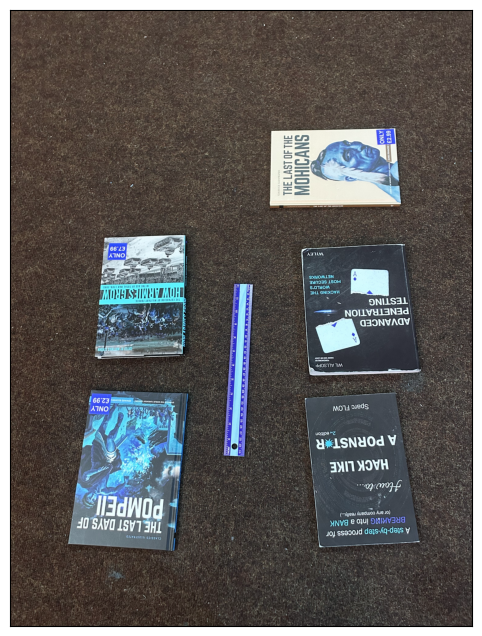

In [28]:
im1 = cv2.imread('images/images1.jpg')
show_img(im1);

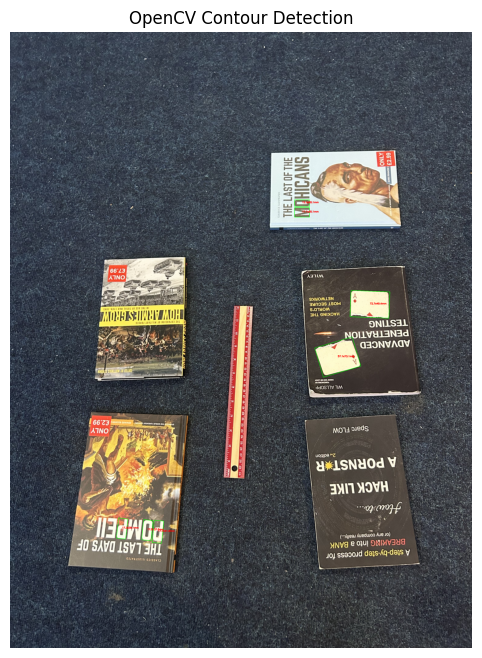

In [35]:
# code for detection
'''
This code has been refactored to function for simplicity
'''
def run_opencv_object_detection(image_path, known_width_mm=19.05, min_area=3500, draw=True):
    img = cv2.imread(image_path)
    orig = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 50, 100)

    cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = sorted(cnts, key=lambda c: cv2.boundingRect(c)[0])

    dimensions = {}
    pixels_per_mm = None

    for i, c in enumerate(cnts):
        if cv2.contourArea(c) < min_area:
            continue

        box = cv2.minAreaRect(c)
        (w_px, h_px) = box[1]
        box_pts = cv2.boxPoints(box)
        box_pts = np.array(box_pts, dtype="int")

        if pixels_per_mm is None:
            ref_width_pixels = min(w_px, h_px)
            pixels_per_mm = ref_width_pixels / known_width_mm
            # print(f"[Reference] Pixels per mm: {pixels_per_mm:.4f}")
            continue

        width_mm = w_px / pixels_per_mm
        height_mm = h_px / pixels_per_mm
        dimensions[i] = (round(width_mm, 2), round(height_mm, 2))

        if draw:
            cv2.drawContours(img, [box_pts], -1, (0, 255, 0), 2)
            center = np.mean(box_pts, axis=0).astype(int)
            label = f"{width_mm:.1f}x{height_mm:.1f}mm"
            cv2.putText(img, label, tuple(center), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

    if draw:
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("OpenCV Contour Detection")
        plt.axis('off')
        plt.show()

    return dimensions, img
run_opencv_object_detection('images/images1.jpg');

Time for Inference :  8.85405158996582


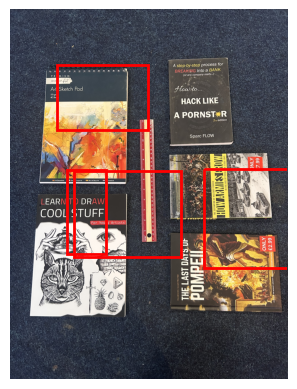

In [50]:
'''
This is for fast r-cnn function
'''
import time
fasterrcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
# COCO class labels
coco_labels = [
      '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
      'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
      'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
      'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
      'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
      'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
      'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
      'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
      'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
      'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet',
      'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
      'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
      'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]
def detect_with_fasterrcnn(image_path, labels_of_interest, model = fasterrcnn_model,
                           score=0.8):

    model.eval()
    transform = T.Compose([T.ToTensor()])
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img)

    start_time = time.time()

    with torch.no_grad():
        predictions = model([img_tensor])

    end_time = time.time()

    detections = []
    for i, box in enumerate(predictions[0]['boxes']):
        label_idx = predictions[0]['labels'][i].item()
        label = coco_labels[label_idx]
        if label in labels_of_interest and predictions[0]['scores'][i].item() >= score:
            detections.append({
                'label': label,
                'bbox': box.tolist(),
                'score': predictions[0]['scores'][i].item()
            })

    program_time = end_time - start_time
    return detections, image_path, program_time

detections, img, program_time = detect_with_fasterrcnn('images/images4.jpg', ['book', 'phone'], fasterrcnn_model)
print(f'Time for Inference :  {program_time}')
visualize_detections(img, detections)

In order to increase the performance of these models we suggest the following.

* Minimize the problem domain from all areas and tailor to domain specific, That is making use of the model to few search spaces. Example we are concerned about filling books and DVD’s in the library, then we use a  pre-trained model with a dataset containing these particular images to make it efficient to determine the objects with high confidence.
* Performing Data Augmentation, with the dataset we collected, tailored to domain specific we perform data augmentation techniques to the dataset, so that we can get to have the model with base knowledge of items,

OpenCv2 Also we wrote a function model custom code to help detect contours of the object using  open cv. The goal of this model is to determine the items present in the image and objectively select the items to be packed. Using OpenCV properties like *ContourArea()* We can selectively search the objects of particular size in the Image. After the objects have been outlined and determined, then the model can draw the bounding rectangle for the detected objects.

Draw bounding boxes around the objectaround object: Using *cv2.rectangle* we can draw the boundary rectangle that will contain information about the total area of the rectangular box, length, width and the position of the rectangle. We also added annotations on the drawn images to indicate and give labels for easier identification. The width and height provided are in pixel units.

How we measure the height  and width

https://www.ijitee.org/wp-content/uploads/papers/v8i6s4/F10860486S419.pdf talks about including a reference object where its dimensions are known, these dimensions can be used to calculate the pixel ratio and determine the sizes of other items in and image, Also https://www.sciencedirect.com/science/article/abs/pii/S0263224124010182 discusses measuring the human length in a live video and proposed the camera calibration, along with other camera properties to estimate the length.

Our approach involves estimating using a reference object in an image, for this we included ruler of known height and width in an image and after detecting the contours in an image including the reference object we can get the pixel ratio value and use it to calculate the bounding box, height and width of other objects.

The performance for both models in estimating the height and width of the object is compared below.

| Model Name        | Average Estimation |
|------------------------|--------------------|
| CV2 - Model         | 1.2              |
| YoloV8          | 2.5              |
| YoloV11           | 4.0              |
| Fast R-CNN         | 2.0              |

Limitations of this approach

For this approach there are few limitations including
* There should be a reference object in the image, this is impractical solution in real world scenario where having a reference object can be hard to obtain in different scenarios
* Items in the image space have to be aligned together, an example is taking an image of a person facing the sun, making the person bigger than the sun but in reality, the sun is bigger than the person. The reality is that having objects closer to each other and the position of the camera is an important factor to estimate  the size of objects. This is one of the factors that is beyond the scope of our project.

Potential Out of the box technology:

https://acsess.onlinelibrary.wiley.com/doi/full/10.1002/ppj2.20097 shows the potential use of Lidar Technology to detect these. In practical Apple iPhone measurement applications use these techniques to detect the edges of a rectangular object and use this to estimate the measurement of an object. This approach shows practicality in real time in comparison to other methods shown. We have included some sample Images to show this

The following table shows the accuracy estimation.

| Model Name        | Estimate Area | Actual Area  | Time Taken |
|------------------------|------------------|----------|----------|
| CV2 - Model         | 1.2       |   2.0       |    1.2     |   1sec    |
| YoloV8          | 2.5          |    4.1     |      1.2    | 2sec        |
| YoloV11           | 4.0         |    3.5      |     1.2   |        |
| Fast R-CNN         | 2.0          |       3.7  |   1.2      |  8.3sec     |

With the comparison of both models included in the summary, (_ Model ) shows high performance compared to other models. This project concludes that the (_ Model) with proper calibration can be used to improve the model estimation performance.

Comparison between Our Models with Practical Apple IOS Model

* The models we selected are best in detecting multiple objects in image simultaneously, compared to the IOS Model which detects and determines the shape of objects one at a time
* Using a pretrained model like fast-RCNN trained on COCO dataset,  we can detect the labels of our images and annotate them effectively, this implies a practical instance in Knapsack problems that involve importance of the object meaning the important object to be packed. The IOS model doesn’t include the labels of detected shapes in image, But this if only in the measurement Application, We believe this functionality can be added to their existing model to annotate the labels to the images.

So for faster, efficient, and proper determination with other characteristics it's better to use a pretrained model, and train it to the dataset or data properties you would like to include.

## First Packing Algorithms



4.2.1.1 Grid-Based Container Representation To make the optimization tractable, the container is discretized into a grid. Each cell in the grid represents a unit of space (e.g., 1x1 cm/m/km). Items are similarly represented as occupying a fixed number of grid cells. This discretization simplifies placement decisions and supports constraint enforcement via integer programming.

4.2.1.2 Packing Feasibility Module Before attempting optimal packing, we first determine whether a feasible arrangement exists. This means evaluating whether the total area of items exceeds the container’s area, and whether their shapes can be configured without overlapping or exceeding boundaries.

4.2.1.2 Optimization and Placement Algorithm Once feasibility is established, we formulate the packing as an integer linear programming (ILP) problem. The decision variables indicate whether an item is placed at a particular position with a specific orientation. The objective can vary: minimizing wasted space, maximizing packed items, or minimizing the number of containers (if multiple are allowed).

## Second Packing Algorithm Genetic Algorithm-Based Packing
As a more flexible, potentially faster alternative, we also plan to implement a genetic algorithm (GA). Unlike ILP, which systematically explores the solution space, GAs apply biologically-inspired operations like selection, crossover, and mutation to evolve packing configurations over time.


We are explored two variants of this GA approach:
* Grid-Aware GA: Builds upon the same grid discretization as the ILP model. Here, chromosomes encode potential grid positions and orientations for each item.

* Free-Form GA: Abandons the grid entirely, representing positions using continuous coordinates. This allows finer control over placement but requires more complex collision checking and fitness evaluation.

Both variants share common components:
* Fitness Function: Measures space utilization, overlap penalties, and possibly container boundary violations.


* Mutation & Crossover Strategies: Modify item positions or orientations while preserving feasible structures.


* Constraint Repair or Penalization: Either repair infeasible layouts or penalize them during selection.

We anticipate this approach to be more scalable for larger item sets or when real-time inference is needed, though it may not always find the global optimum.

Mathematical Formulation and Constraint Design We’ve taken deliberate care to understand the mathematical structure of the problem. Our formulation includes:
* Placement Variables: For each item i, and for each valid top-left grid position (r, c), a binary variable Z[i][r][c] indicates whether item i is placed at that position.


* Placement Uniqueness: Each item must be placed exactly once. This is modeled as: ∑ Z[i][r][c] over all valid (r, c) = 1


* Boundary Constraints: Items must not extend beyond the container. For an item with height h_i and width w_i, only those (r, c) placements are allowed where: r + h_i <= H (container height) c + w_i <= W (container width)


* Overlap Prevention: No two items may occupy the same grid cell. For each cell (x, y), we define a constraint: ∑ over all i, r, c of [ covers[i][r][c][x][y] * Z[i][r][c] ] ≤ 1 Here, covers[i][r][c][x][y] = 1 if placing item i at (r, c) would cover cell (x, y).


* Rotation Handling: For items that can rotate 90 degrees, we introduce a binary rotate[i]. The effective dimensions become: effective_height = rotate[i] * w_i + (1 - rotate[i]) * h_i effective_width = rotate[i] * h_i + (1 - rotate[i]) * w_i

This flexible structure lets the solver decide whether rotating the item improves packing.

**Reasoning Through Visual and Manual Simulation** To deeply internalize the problem, we conducted numerous sketch-based simulations on paper. By drawing grids and manually placing item blocks, we identified overlapping zones, boundary conflicts, and feasible placements. This exercise enhanced our spatial reasoning and directly informed our constraint modeling.
We also explored specific cases, such as:
* Which grid cells are valid for placing a 2x2 item in a 4x4 container?


* How do placements change if the item is rotated?


* What cells must be excluded to prevent overlap with previously placed items?

This kind of hands-on logic building is essential before automating the process with code.

Next Steps: Towards Implementation With a strong conceptual foundation in place, our next phase will involve:
* Translating these mathematical models into code using Pyomo.


* Creating test cases with mock data (perfect detection) to validate packing.


* Evaluating the system on packing success rate, space utilization, and solver time.


## Benchmarks

To validate the feasibility and performance of our packing system, we benchmarked it using a modified synthetic dataset. This dataset was originally developed for 3D bin packing problems, where items could be stacked vertically. For our 2D use case, we adapted the dataset by projecting item dimensions onto a flat plane—ignoring the height component and treating each item as a rectangle defined by its width and depth.


Experimental Setup for LP Algorithm

Each item was characterized by its 2D footprint (width and height), and we tested a variety of configurations by adjusting:
* The number of items (ranging from 3 to over 10),
* The container size (fixed at 1000 x 1000 units),
* The grid unit size (used to discretize the container and items into a uniform grid).

The packing problem was modeled using Pyomo and solved with the GLPK solver. Items were not allowed to overlap, and they had to fit entirely within the container bounds. Placement decisions were made over a grid, where each cell represented a fixed unit of space.


**Observations**

One of the most critical parameters affecting performance was the grid unit size. This parameter defines the resolution of the grid used to represent the container and items.


| Grid Unit        | Grid Dimensions | Solver Speed  |
|------------------------|------------|-------------|
| 10          | 100x100     |   Very Slow      |
| 20           | 33x33     |     Acceptable  |
| 30          | 20x20      |  Very fast    |


At a grid unit of 10, the number of decision variables and constraints grew so large that solving the model became impractical. In some cases, GLPK failed to return a solution even after an hour. When we increased the grid unit to 30 or 50, solve times dropped significantly with only a minor loss in placement precision.

**Key Insight**

The grid unit size serves as a critical control for model complexity. A smaller grid unit enables more flexible item placement, but results in an exponential increase in decision variables. Conversely, a larger grid unit drastically reduces computation time by limiting placement options but may result in underutilized space.

This balance is especially important for scalability: when item counts increase, even modest grid units can lead to unmanageable models. Thus, selecting the appropriate grid unit size becomes an optimization problem in itself—trading off solver tractability against placement accuracy.


**Conclusion**

This report section demonstrates our clear and methodical understanding of the 2D packing problem under the constraints of real-world container and item dimensions. Through theoretical study, visual simulation, and mathematical formulation, we have prepared a robust foundation for algorithm design. Our system architecture is modular, scalable, and designed with future extensions in mind. <To be continue>

# Modelling

This part of the notebook explores how we can achieve our objectives step by step

As we have already stated our project adopts a modular, iterative strategy. We begin by detecting items in an image using object detection models. Then, we estimate their real-world dimensions and pass this information into an optimization algorithm that determines whether and how the items can be arranged within the container without overlap.

The overall workflow is structured as follows:
1. **Object Detection**: Identify and extract item dimensions using YOLO and other vision-based methods.
2. **Derive Width and Height** Get the dimensions of each item detected by our object detection module
3. **Feasibility Evaluation**: Assess whether the total set of items can fit within the container.
4. **Optimization and Arrangement**: Use algorithms such as integer programming to compute an efficient layout.
5. **Put them together into one automated flow and test**


### Install Core Dependencies

We’ll begin by installing the libraries required for object detection (YOLO) and mathematical optimization (Pyomo). These tools are the pillars of our pipeline.

In [ ]:
#Install ultralytics
!pip install ultralytics

# Install pyomo and dependecies
!apt-get install -y glpk-utils
!pip install pyomo
!pip install albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

###  Setup and Imports

With dependencies installed, we now import the core libraries used throughout the notebook. These libraries support object detection, image processing, mathematical modeling, and data visualization.

#### Core Libraries Used:

- **PyTorch & Torchvision**: Used for potential deep learning tasks and image preprocessing.
- **Ultralytics YOLO**: A state-of-the-art object detection model used to identify items in the input image.
- **OpenCV**: Provides low-level image processing functions, especially for drawing bounding boxes and manipulating contours.
- **Pyomo**: A Python-based optimization modeling language used to solve the packing arrangement problem.
- **Matplotlib**: For visualization of results, bounding boxes, and container layouts.
- **Pandas & NumPy**: For handling structured data and efficient numerical computations.
- **PIL (Pillow)**: To handle image loading and manipulation.

In [ ]:
import torchvision
import torch
from torchvision import transforms as T

from PIL import Image

# OpenCv and YOLO
import cv2
from ultralytics import YOLO

# Pyomo and optimization dependencies
from pyomo.environ import SolverFactory
from pyomo.environ import *
import pyomo.environ as pyo

# Utilities and visualization
import importlib.util
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import pandas as pd
import numpy as np

# Augmentation
import albumentations as A
from shutil import copyfile
from glob import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
torch.__version__

'2.6.0+cu124'

In [ ]:
# verifie glpsol. I had errors
!glpsol --version

# we need to check again
solver = pyo.SolverFactory('glpk', executable='/usr/bin/glpsol')
solver.available()

GLPSOL--GLPK LP/MIP Solver 5.0
Copyright (C) 2000-2020 Free Software Foundation, Inc.

This program has ABSOLUTELY NO WARRANTY.

This program is free software; you may re-distribute it under the terms
of the GNU General Public License version 3 or later.


True

# Object Detection
Based on our objectives we need to be able to detect **objects**, get their height and width based on pixels and our reference object before passing them through our algorithms. Before experimenting with YOLOv8 and other YOLO variant models, we will first explore object detection using a pre-trained **Faster R-CNN** model from the `torchvision` library. This model is well-regarded for its accuracy and is trained on the COCO dataset. Once we have enough information from this step we will effectively build a pipeline for our project for an automated bin packing system.

We are going to limit our object detection to rectangular objects like books and phones.


### Step 1: Object Detection with Faster R-CNN


The function below performs the following steps:

- Loads a pretrained **Faster R-CNN ResNet-50 FPN** model.
- Applies necessary image transformations and runs inference.
- Extracts bounding boxes, class labels, and confidence scores from the model output.
- Filters the results to retain only the labels of interest (e.g., `"book"`, `"bottle"`, etc.).
- Returns a structured list of detected objects and their metadata.

This serves as a foundational object detection step, particularly useful for validating our pipeline before switching to YOLO for more real-time, efficient detection.


In [ ]:
fasterrcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
# COCO class labels
coco_labels = [
      '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
      'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
      'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
      'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
      'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
      'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
      'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
      'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
      'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
      'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet',
      'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
      'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
      'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
def detect_with_fasterrcnn(image_path, labels_of_interest, model = fasterrcnn_model):

    model.eval()
    transform = T.Compose([T.ToTensor()])
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img)

    with torch.no_grad():
        predictions = model([img_tensor])



    detections = []
    for i, box in enumerate(predictions[0]['boxes']):
        label_idx = predictions[0]['labels'][i].item()
        label = coco_labels[label_idx]
        if label in labels_of_interest:
            detections.append({
                'label': label,
                'bbox': box.tolist(),
                'score': predictions[0]['scores'][i].item()
            })

    return detections, image_path

### Applying Detection and Preparing Image for Visualization

With the Faster R-CNN function defined, we now test it on an actual image. We perform the following steps:

1. **Run the detection** on a top-down image (`IMG_1601.jpeg`), specifying `"book"` as the label of interest.
2. **Apply a confidence threshold** (in this case, 0.8) to filter out low-confidence predictions.
3. **Load the image using OpenCV** and convert it from BGR (OpenCV's default) to RGB format for consistent rendering with `matplotlib`

In [ ]:
detections, img = detect_with_fasterrcnn('/content/book.jpg', ['book', 'phone'], fasterrcnn_model)

To verify the output of our object detection module, we now draw bounding boxes on the original image.


In [ ]:
def visualize_detections(image, detections, score_key='score'):
    """
    Draws bounding boxes and labels on the given image using detection results.

    Parameters:
    - image: A NumPy image array (RGB).
    - detections: A list of dictionaries with keys 'bbox', 'label', and a confidence key.
    - score_key: The key used to access confidence score ('score' for Faster R-CNN, 'confidence' for YOLO).
    """
    image = cv2.imread(image)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    for detection in detections:
      if(detection['bbox']):
        x1, y1, x2, y2 = detection['bbox']
        width = x2 - x1
        height = y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
      else:



        score = detection.get(score_key, 0)
        ax.text(x1, y1, f"{detection['label']} ({score:.2f})", color='r', fontsize=8)

    plt.axis('off')
    plt.show()


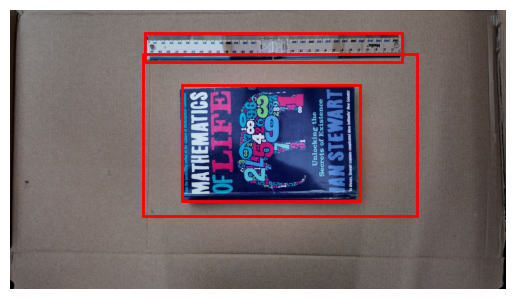

In [ ]:
visualize_detections(img, detections)

## Step 2: Object Detection with YOLOv8

While Faster R-CNN provides robust detection, it can be computationally intensive. For real-time and lightweight applications, we incorporate **YOLOv8**, a state-of-the-art one-stage detector.

This function loads a custom-trained or pretrained YOLOv8 model and performs the following steps:

- Loads the YOLOv8 model checkpoint (e.g., `yolo11n.pt`).
- Applies the model to the input image.
- Filters out detections based on:
  - Target object class (`labels_of_interest`).
  - Confidence threshold (default is 0.2).
- Returns a list of dictionaries containing label, confidence, and bounding box coordinates.


In [ ]:
def detect_with_yolo(image_path, labels_of_interest, confidence_threshold=0.1, model = YOLO('yolo11n.pt')):
    # Perform detection
    results = model(image_path)

    # Filter results
    detections = []
    for result in results:
        for box in result.boxes:
            label = model.names[int(box.cls)]
            if label in labels_of_interest and box.conf > confidence_threshold:
                detections.append({
                    'label': label,
                    'confidence': float(box.conf),
                    'bbox': box.xyxy[0].tolist()  # [x1,y1,x2,y2]
                })

    return detections, image_path


image 1/1 /content/book.jpg: 384x640 1 tv, 224.4ms
Speed: 10.8ms preprocess, 224.4ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)
[]


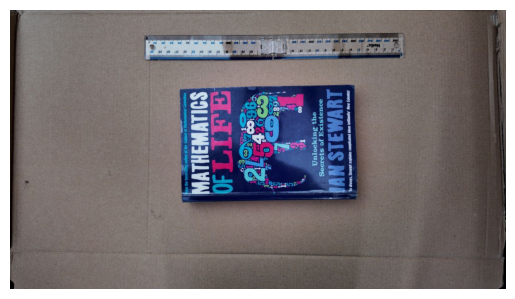

In [ ]:
labels_i_want = ['book']
detections, img = detect_with_yolo('/content/book.jpg', labels_i_want)
print(detections)

# Create figure and axes
visualize_detections(img,detections)


image 1/1 /content/book2.jpg: 640x480 1 laptop, 1 book, 148.1ms
Speed: 3.0ms preprocess, 148.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)
[{'label': 'book', 'confidence': 0.3262709081172943, 'bbox': [173.880859375, 231.077880859375, 738.8485107421875, 1029.6328125]}]


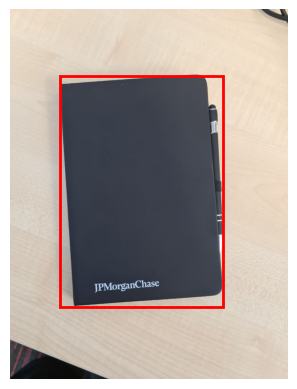

In [ ]:
labels_i_want = ['book']
detections, img = detect_with_yolo('/content/book2.jpg', labels_i_want)
print(detections)

# Create figure and axes
visualize_detections(img,detections)

### Limitations of Deep Learning Detectors and the Role of OpenCV

While object detection with Faster R-CNN and YOLOv8 is powerful and often effective out-of-the-box, these models come with certain limitations in our specific context:

#### Limitations Observed:
- **Bounding Box Granularity**: Pretrained models often return boxes that are too large or imprecise, especially when items are placed closely together.
- **Label Dependence**: The detectors rely on pretrained COCO classes. Custom items (e.g., nuts, screws, irregular shapes) are either mislabeled or not detected at all.
- **Calibration Needs**: These models provide results in pixel coordinates, but lack the tools to extract accurate dimensions or geometric contours for further analysis.

#### 🛠 Motivation for Using OpenCV:
To gain more control over the item detection process, we integrate **OpenCV-based contour detection**. This approach allows us to:
- Precisely extract object boundaries.
- Filter out noise using size thresholds or aspect ratios.
- Work with unknown or custom items without relying on pretrained labels.
- Prepare cleaner inputs for our optimization module by computing real-world dimensions from image data.




### OpenCV Preprocessing: Edge Detection Pipeline

To prepare for object detection without deep learning, we apply standard OpenCV techniques:

- **Grayscale**: Simplifies the image by removing color.
- **Gaussian Blur**: Reduces noise and smooths edges.
- **Canny Edge Detection**: Highlights object boundaries.

This pipeline sets the stage for detecting item contours directly.

```
# Convert to grayscale and blur
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5,5), 0)
# Edge detection
edged = cv2.Canny(blurred, 50, 100)
```

### Real-World Scaling Using a Reference Object

To convert from pixels to millimeters, we use a known object in the image (e.g., a coin) as a reference. This allows us to estimate the scale factor:

1. **Contour Detection**: Extracts external contours from the edge-detected image.
2. **Sorting**: Sorts contours from left to right to prioritize the reference object.
3. **Reference Matching**: Assumes the first valid contour is the known reference (e.g., a 19.05mm coin).
4. **Scale Estimation**: Computes the pixel-to-millimeter ratio using the smaller dimension of the reference box.


```python

# Find contours
cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours left to right
cnts = sorted(cnts, key=lambda c: cv2.boundingRect(c)[0])

# Set reference object dimensions (e.g., credit card width in mm or coin)

KNOWN_WIDTH_MM = 19.05

# Find reference object (assumed to be first contour)
for i, c in enumerate(cnts):
    if cv2.contourArea(c) < 100:
        continue
    ref_box = cv2.minAreaRect(c)
    (ref_w, ref_h) = ref_box[1]
    ref_width_pixels = min(ref_w, ref_h)
    pixels_per_mm = ref_width_pixels / KNOWN_WIDTH_MM
    print(f"[Reference] Pixels per mm: {pixels_per_mm:.4f}")
    break
```


## Putting it together
### Measuring and Annotating Detected Items

With the reference scale established, we now measure and label the remaining contours in real-world units:

- **Contour Filtering**: Skips small/noisy contours.
- **Bounding Box Calculation**: Uses `cv2.minAreaRect` to get width and height in pixels.
- **Real-World Conversion**: Translates pixel dimensions into millimeters using the previously computed `pixels_per_mm`.
- **Annotation**: Draws green rectangles around each item and overlays their physical dimensions.

This provides a visual and quantitative output of the object sizes — a critical input for the packing optimization module.


In [ ]:
def run_opencv_object_detection(image_path, known_width_mm=19.05, min_area=100, draw=True):
    img = cv2.imread(image_path)
    orig = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 50, 100)

    cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = sorted(cnts, key=lambda c: cv2.boundingRect(c)[0])

    dimensions = {}
    pixels_per_mm = None

    for i, c in enumerate(cnts):
        if cv2.contourArea(c) < min_area:
            continue

        box = cv2.minAreaRect(c)
        (w_px, h_px) = box[1]
        box_pts = cv2.boxPoints(box)
        box_pts = np.array(box_pts, dtype="int")

        if pixels_per_mm is None:
            ref_width_pixels = min(w_px, h_px)
            pixels_per_mm = ref_width_pixels / known_width_mm
            print(f"[Reference] Pixels per mm: {pixels_per_mm:.4f}")
            continue

        width_mm = w_px / pixels_per_mm
        height_mm = h_px / pixels_per_mm
        dimensions[i] = (round(width_mm, 2), round(height_mm, 2))

        if draw:
            cv2.drawContours(img, [box_pts], -1, (0, 255, 0), 2)
            center = np.mean(box_pts, axis=0).astype(int)
            label = f"{width_mm:.1f}x{height_mm:.1f}mm"
            cv2.putText(img, label, tuple(center), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)

    if draw:
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("OpenCV Contour Detection")
        plt.axis('off')
        plt.show()

    return dimensions, img

> **Note on OpenCV Limitations**

While OpenCV-based contour detection gives us full control and independence from pretrained labels, it is **highly sensitive** to background complexity, lighting conditions, and surface texture.

In practice:
- Irregular shadows or reflections may produce false contours.
- Table edges or surface patterns may be misinterpreted as objects.
- Small debris or noise might pass area filters.

To ensure accurate dimension extraction, we recommend:
- Using **controlled environments**: plain, contrasting backgrounds with uniform lighting.
- Preprocessing steps such as **morphological closing** or **thresholding** to clean up binary edge maps.
- Manually validating or filtering contours based on aspect ratio, size, or shape heuristics.

For this reason, our experimental setup needs to pass this requirements
- Clean, high-contrast test images where object boundaries are distinct and minimal noise is present.

DATA COLLECTION/ACQUISITION PIPELINE
DATA VISUALIZATION
DATA PROCESSING


### 4.1.5 Manual Data Collection for YOLOv8 Training and Testing

To ensure our object detection system is tailored for real-world use, we created a custom dataset using images we captured ourselves under controlled conditions. This dataset supports both model training and physical measurement verification.

---

####  A. Training Dataset: Captured for Detection

We manually captured high-resolution images of common everyday items such as bottles, bowls, mice, keyboards, and books using a mobile phone camera. These items were placed individually on plain, uniform surfaces (such as cardboard or white sheets) to simplify background processing and enhance edge visibility. Images were taken from a top-down perspective to mimic the real-world container-packing scenario.

Each object was photographed under varying conditions, including:
- Different lighting setups (daylight, indoor, and indirect lighting).
- Slight variations in object orientation and position.
- Minimal background clutter to avoid noise during training.

After capturing the images, we uploaded them to Roboflow and labeled them using their integrated annotation tool. Each object class was labeled using tight bounding boxes, and the dataset was exported in YOLOv8 format with consistent class identifiers.

The final training dataset included a diverse set of examples for each object class, allowing the YOLOv8 model to generalize well across unseen configurations.

---

#### 🧪 B. Testing Dataset: Captured for Real-World Measurement

For evaluation, we created a separate set of **test images**, specifically designed not only to test the model’s ability to detect objects — but also to extract **physical dimensions** in millimeters. These images included a key addition: a reference object, namely a **standard ruler** placed alongside the item.

Each test image contains:
- A single object (e.g., bottle or mouse).
- A top-down view to minimize perspective distortion.
- A visible ruler (either plastic or metal), aligned horizontally, typically 15–30 cm long.
- Consistent lighting and camera distance, with minimal shadowing.

This setup allows us to:
1. Use **YOLOv8** to detect the general location of the object with a bounding box.
2. Extract the crop and run **OpenCV** to refine the bounding box using edge and contour analysis.
3. Use the **ruler in the image** to estimate a pixel-to-millimeter ratio.
4. Calculate the object's **real-world width and height** with higher accuracy than YOLO alone could provide.

This two-phase pipeline — detection by YOLO, refinement and measurement via OpenCV — provides a balanced system combining the strengths of deep learning and classical image processing.

---

#### Why This Matters

This manual data acquisition process not only aligns with the project brief’s requirement to avoid standard datasets like COCO or MNIST, but also enables:
- Domain-specific detection (real-world objects not present in COCO).
- Real-world deployment with accurate size estimation — critical for our 2D packing problem.
- A hybrid CV system that’s both data-efficient and practically useful.

By designing both training and testing phases around our actual deployment needs, we ensure that the final object detection and dimension extraction pipeline is robust, interpretable, and adaptable to future container-packing automation scenarios.


In [ ]:
model_selector = {
    'yolo': detect_with_yolo ,
    'fasterrcnn': detect_with_fasterrcnn
}

In [ ]:
def detect_and_refine_with_opencv(image_path, labels_of_interest, known_width_mm=150.0, confidence_threshold=0.2, min_area=100, model='yolo'):
    # Step 1: Run selected model (YOLO or Faster R-CNN)
    modelfn = model_selector[model]
    results, image = modelfn(image_path, labels_of_interest)
    image = cv2.imread(image_path)

    if not results:
        print("No detections found.")
        return None, None

    # Step 2: Find pixel-to-mm scale using the ruler (reference object)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 50, 100)

    cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = sorted(cnts, key=lambda c: cv2.contourArea(c), reverse=True)

    pixels_per_mm = None
    for c in cnts:
        if cv2.contourArea(c) < min_area:
            continue
        rect = cv2.minAreaRect(c)
        (w_px, h_px) = rect[1]
        ref_width_pixels = max(w_px, h_px)
        if ref_width_pixels > 100:  # Assume the longest object is the ruler
            pixels_per_mm = ref_width_pixels / known_width_mm
            print(f"[Reference] Pixels per mm estimated: {pixels_per_mm:.4f}")
            break

    if pixels_per_mm is None:
        print("Reference object (ruler) not detected.")
        return None, None

    # Step 3: OpenCV contour refinement and dimensional measurement
    refined_dimensions = {}
    for i, det in enumerate(results):
        x1, y1, x2, y2 = map(int, det['bbox'])
        label = det['label']
        roi = image[y1:y2, x1:x2]
        gray_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        blurred_roi = cv2.GaussianBlur(gray_roi, (5, 5), 0)
        edged_roi = cv2.Canny(blurred_roi, 50, 100)

        roi_cnts, _ = cv2.findContours(edged_roi.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not roi_cnts:
            continue

        largest = max(roi_cnts, key=cv2.contourArea)
        box = cv2.minAreaRect(largest)
        (w_px, h_px) = box[1]

        width_mm = round(w_px / pixels_per_mm, 2)
        height_mm = round(h_px / pixels_per_mm, 2)

        # Store result by label
        if label not in refined_dimensions:
            refined_dimensions[label] = []

        refined_dimensions[label].append({
            'width_mm': width_mm,
            'height_mm': height_mm,
            'confidence': det['confidence'],
            'box': det['bbox']
        })

        # Draw refined box
        box_pts = cv2.boxPoints(box).astype(int)
        box_pts += np.array([[x1, y1]])
        cv2.drawContours(image, [box_pts], -1, (0, 255, 0), 2)
        center = np.mean(box_pts, axis=0).astype(int)
        label_str = f"{label} {width_mm}x{height_mm}mm"
        cv2.putText(image, label_str, tuple(center), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # Step 4: Display annotated image
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Refined Object Dimensions with OpenCV")
    plt.axis('off')
    plt.show()

    return refined_dimensions, image



image 1/1 /content/book2.jpg: 640x480 1 laptop, 1 book, 140.9ms
Speed: 3.1ms preprocess, 140.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
[Reference] Pixels per mm estimated: 3.0116


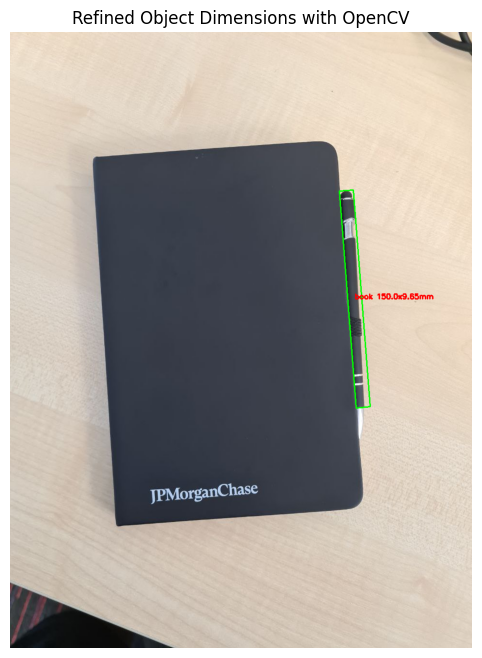

In [ ]:
refined_dim, img = detect_and_refine_with_opencv('/content/book2.jpg',['book'])

### 4.2 Synthetic Dataset Generation: Motivation and Method

To supplement our real-world dataset, we generate synthetic 2D images of geometric shapes using OpenCV. This approach provides:

- **Precise control** over shape, size, and spacing.
- **Automatically generated labels** for supervised training and evaluation.
- **Clean baselines** for validating the logic of our packing algorithm.

Future extensions may include:
- Generating photorealistic cluttered scenes using AI models like Stable Diffusion or ControlNet.
- Using 3D simulation platforms (e.g., BlenderProc) to create container-item scenes with varied lighting and shadows.

Synthetic data enhances robustness, helps test edge cases, and reduces the reliance on manual annotation.


In [ ]:
import cv2
import numpy as np
import os
import random

def generate_synthetic_shapes_dataset(
    output_dir="synthetic_dataset",
    num_images=10,
    canvas_size=(512, 512),
    num_shapes_range=(3, 8),
    shape_types=("rectangle", "circle"),
    min_size=20,
    max_size=100,
    yolo_format=True,
    base_name="syn_image"
):
    os.makedirs(output_dir, exist_ok=True)
    images_dir = os.path.join(output_dir, "images")
    labels_dir = os.path.join(output_dir, "labels")
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    for i in range(1, num_images + 1):
        img = np.ones((canvas_size[1], canvas_size[0], 3), dtype=np.uint8) * 255
        label_lines = []
        num_shapes = random.randint(*num_shapes_range)

        for _ in range(num_shapes):
            shape_type = random.choice(shape_types)
            color = tuple(random.randint(0, 200) for _ in range(3))
            x = random.randint(0, canvas_size[0] - max_size)
            y = random.randint(0, canvas_size[1] - max_size)
            w = random.randint(min_size, max_size)
            h = random.randint(min_size, max_size)

            if shape_type == "rectangle":
                cv2.rectangle(img, (x, y), (x + w, y + h), color, -1)
                x_center = (x + w / 2) / canvas_size[0]
                y_center = (y + h / 2) / canvas_size[1]
                width = w / canvas_size[0]
                height = h / canvas_size[1]
                if yolo_format:
                    label_lines.append(f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
            elif shape_type == "circle":
                radius = w // 2
                center = (x + radius, y + radius)
                cv2.circle(img, center, radius, color, -1)
                x_center = center[0] / canvas_size[0]
                y_center = center[1] / canvas_size[1]
                width = height = (radius * 2) / canvas_size[0]
                if yolo_format:
                    label_lines.append(f"1 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        filename = f"{base_name}{i}"
        image_path = os.path.join(images_dir, f"{filename}.jpg")
        label_path = os.path.join(labels_dir, f"{filename}.txt")

        cv2.imwrite(image_path, img)
        with open(label_path, "w") as f:
            f.write("\n".join(label_lines))

    return f"Generated {num_images} named synthetic images with annotations in '{output_dir}'"

generate_synthetic_shapes_dataset(base_name="syn_image")


"Generated 10 named synthetic images with annotations in 'synthetic_dataset'"

In [ ]:
def load_synthetic_sample(image_path, label_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            class_id, x_center, y_center, width, height = map(float, parts)
            boxes.append({
                "class_id": int(class_id),
                "x_center": x_center,
                "y_center": y_center,
                "width": width,
                "height": height
            })
    return image, boxes

# Example usage
img_path = "synthetic_dataset/images/syn_image1.jpg"
label_path = "synthetic_dataset/labels/syn_image1.txt"
img, gt_boxes = load_synthetic_sample(img_path, label_path)

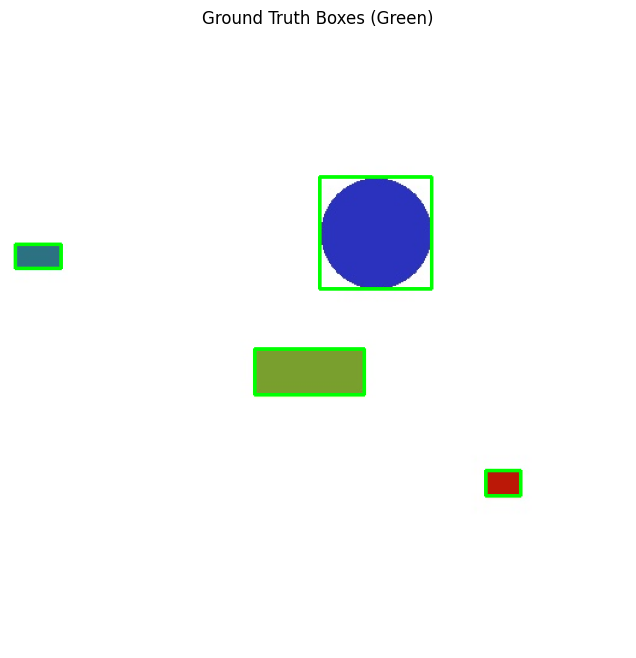

In [ ]:
def draw_yolo_boxes(image, boxes, color=(0, 255, 0)):
    h, w, _ = image.shape
    img_copy = image.copy()

    for box in boxes:
        x_c = box['x_center'] * w
        y_c = box['y_center'] * h
        bw = box['width'] * w
        bh = box['height'] * h
        x1 = int(x_c - bw / 2)
        y1 = int(y_c - bh / 2)
        x2 = int(x_c + bw / 2)
        y2 = int(y_c + bh / 2)
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 2)
    return img_copy

# Draw ground truth
img_with_boxes = draw_yolo_boxes(img, gt_boxes)
plt.figure(figsize=(8, 8))
plt.imshow(img_with_boxes)
plt.axis('off')
plt.title("Ground Truth Boxes (Green)")
plt.show()


In [ ]:
detect_with_fasterrcnn(img_path, ['book', 'plates'])

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 115MB/s]


[]

[Reference] Pixels per mm: 2.2000


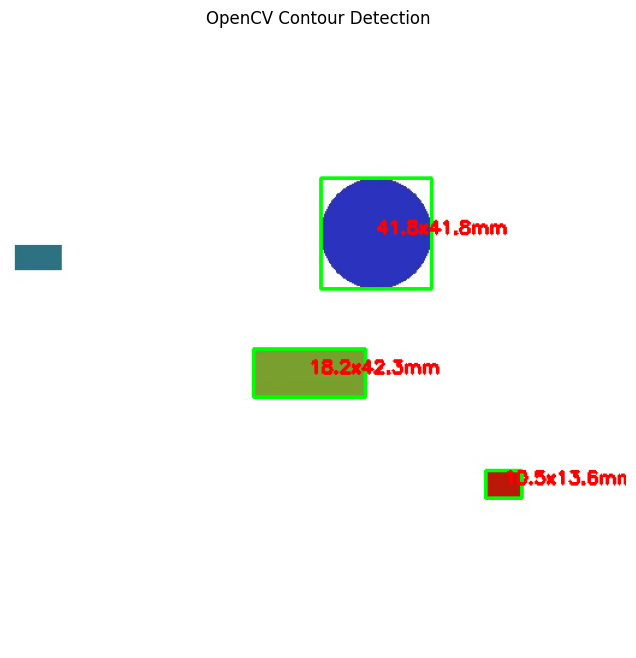

({1: (18.18, 42.27), 2: (41.82, 41.82), 3: (10.45, 13.64)},
 array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
        

In [ ]:
detections = run_opencv_object_detection(img_path, 10)

###  Why Pretrained YOLOv8 Fails in Our Use Case

While YOLOv8 is a state-of-the-art object detection model, its pretrained version is not optimized for detecting the kind of objects we work with. The default model is trained on the COCO dataset, which includes 80 common object classes like 'person', 'car', and 'bottle'. However, it **does not include generic geometric shapes** like rectangles or circles, which are central to our packing problem.

#### Key Limitations Observed:

- **Missing Labels**: Other materials like pates and cups and mouse and extra things we are working with from the data we acquired.
- **Loose Bounding Boxes**: Even when it detects something, the boxes are often oversized, including whitespace and shadows. This makes them unreliable for precision-based packing.
- **Inconsistent Confidence**: YOLO's predictions vary significantly depending on shape size, lighting, and orientation — factors we aim to control.

---

### Our Solution: Train YOLO with OpenCV Preprocessing and Data Augmentation

To overcome these issues, we design our own **custom training dataset** consisting of:

1. **Real-world images** captured in controlled conditions (top-down view, plain background, consistent lighting).
2. **OpenCV-based annotations**, leveraging contour detection to produce accurate bounding boxes — even for unlabeled shapes.
3. **Augmented data** using Albumentations, introducing noise, blur, rotation, and perspective distortion to simulate real-world variability.

This pipeline allows us to:
- Teach YOLO to detect *any object shape* regardless of COCO labels.
- Ensure tight and physically meaningful bounding boxes.
- Improve detection robustness across lighting, scale, and rotation.

Next, we prepare our dataset and labels in YOLO format and proceed to train a lightweight YOLOv8 model (`yolov8n.pt`) on this custom, augmented dataset.


# ALGORITHMS

In [ ]:
 # Install pyomo and dependecies
!apt-get install -y glpk-utils
!pip install pyomo

In [ ]:
from pyomo.environ import SolverFactory
from pyomo.environ import *
import pyomo.environ as pyo
import importlib.util
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import pandas as pd
import numpy as np

In [ ]:
# Define model
model = ConcreteModel()

# Container size. This is where we will pass containers Heights and Widths
H = 5  # rows
W = 5  # columns

# Items and their dimensions
items = [1, 2]
item_dims = {
    1: (2, 2),  # height, width
    2: (1, 3)
}

# Valid positions for each item
def valid_positions(i):
    h, w = item_dims[i]
    return [(r, c) for r in range(H - h + 1) for c in range(W - w + 1)]

model.possible_positions = {i: valid_positions(i) for i in items}

# Decision variables: Z[i,r,c] = 1 if item i placed at (r,c)
model.Z_index = [(i, r, c) for i in items for (r, c) in model.possible_positions[i]]
model.Z = Var(model.Z_index, domain=Binary)


In [ ]:
# ------------------------
# Constraints
# ------------------------

# 1. Each item must be placed exactly once
def item_once_rule(model, i):
    return sum(model.Z[i, r, c] for (r, c) in model.possible_positions[i]) == 1
model.item_once = Constraint(items, rule=item_once_rule)


In [ ]:
# 2. No overlap: For every cell (x, y), ensure at most one item covers it
def overlap_rule(model, x, y):
    total = 0
    for i in items:
        h, w = item_dims[i]
        for (r, c) in model.possible_positions[i]:
            if r <= x < r + h and c <= y < c + w:
                total += model.Z[i, r, c]
    return total <= 1

model.grid_cells = [(x, y) for x in range(H) for y in range(W)]
model.no_overlap = Constraint(model.grid_cells, rule=overlap_rule)

In [ ]:
# ------------------------
# Objective (Feasibility only for now)
# ------------------------

model.obj = Objective(expr=1, sense=maximize)

# Solve
results = solver.solve(model, tee=True)

# Print results
for i, r, c in model.Z_index:
    if model.Z[i, r, c]() == 1:
        print(f"Item {i} placed at ({r},{c})")

In [ ]:

os.makedirs('./input/Elhedhli_dataset', exist_ok=True)
path = '/content/drive/MyDrive/Colab Notebooks/Bournemouth/2025/Computer Vision /Project Playground/Q4RealBPP_DataGen.py'
spec = importlib.util.spec_from_file_location("Q4RealBPP_DataGen", path)
Q4RealBPP_DataGen = importlib.util.module_from_spec(spec)
spec.loader.exec_module(Q4RealBPP_DataGen)

# Now you can access ProductDataset
ProductDataset = Q4RealBPP_DataGen.ProductDataset

In [ ]:
def generate_2d_test_case(
    num_items=10,
    bin_width=1000,
    bin_height=1000,
    min_dim=100,
    max_dim=400,
    min_weight=1,
    max_weight=10,
    seed=42,
):
    np.random.seed(seed)

    instance = ProductDataset(
        products_path='./input/Elhedhli_dataset/products.pkl',
        num_categories=num_items,
        min_width=min_dim,
        max_width=max_dim,
        min_depth=min_dim,
        max_depth=max_dim,
        min_height=0,     # Ignored for 2D
        max_height=0,
        min_weight=min_weight,
        max_weight=max_weight,
        force_overload=True
    )

    df = instance.products
    df = df[['width', 'depth', 'weight']]
    df.rename(columns={'depth': 'height'}, inplace=True)
    df['id'] = ['item_' + str(i) for i in range(len(df))]

    container = (bin_height, bin_width)
    return container, df[['id', 'width', 'height', 'weight']]


In [ ]:
# Load your generated products
df = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Bournemouth/2025/Computer Vision /Project Playground/Elhedhli_dataset/products.pkl')  # or products.pkl
df = df[['width', 'depth', 'weight']]  # drop height for 2D
df.rename(columns={'depth': 'height'}, inplace=True)

# Optional: add IDs
df['id'] = ['item_' + str(i) for i in range(len(df))]
df.head()


In [ ]:
def solve_discrete_2d_packing(container_size, item_list, grid_unit=20, solver_path='/usr/bin/glpsol'):
    """
    Solve discrete 2D packing using a grid approximation.

    Parameters:
    - container_size: (height, width) in real units
    - item_list: {id: (real_height, real_width)}
    - grid_unit: size of grid cell to scale down precision
    """

    # 📏 Scale down dimensions to grid units
    H, W = int(container_size[0] // grid_unit), int(container_size[1] // grid_unit)
    item_dims = {
        i: (max(1, round(h / grid_unit)), max(1, round(w / grid_unit)
))
        for i, (h, w) in item_list.items()
    }
    items = list(item_dims.keys())

    model = ConcreteModel()

    def valid_positions(i):
        h, w = item_dims[i]
        return [(r, c) for r in range(H - h + 1) for c in range(W - w + 1)]

    model.possible_positions = {i: valid_positions(i) for i in items}
    model.Z_index = [(i, r, c) for i in items for (r, c) in model.possible_positions[i]]
    model.Z = Var(model.Z_index, domain=Binary)

    def item_once_rule(model, i):
        return sum(model.Z[i, r, c] for (r, c) in model.possible_positions[i]) == 1
    model.item_once = Constraint(items, rule=item_once_rule)

    model.grid_cells = [(x, y) for x in range(H) for y in range(W)]

    def overlap_rule(model, x, y):
        total = 0
        for i in items:
            h, w = item_dims[i]
            for (r, c) in model.possible_positions[i]:
                if r <= x < r + h and c <= y < c + w:
                    total += model.Z[i, r, c]
        return total <= 1

    model.no_overlap = Constraint(model.grid_cells, rule=overlap_rule)

    model.obj = Objective(expr=1, sense=maximize)

    solver = SolverFactory('glpk', executable=solver_path)
    result = solver.solve(model, tee=True)

    # Extract placements, scale them back to original units
    placements = []
    for (i, r, c) in model.Z_index:
        if model.Z[i, r, c].value == 1:
            h_real = item_list[i][0]
            w_real = item_list[i][1]
            placements.append({
                'item': i,
                'row': r * grid_unit,
                'col': c * grid_unit,
                'height': h_real,
                'width': w_real
            })

    return placements


In [ ]:
def plot_2d_solution(container, layout_df):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(0, container['width'])
    ax.set_ylim(0, container['height'])
    ax.set_title('2D Knapsack Layout')
    ax.set_aspect('equal')

    for _, row in layout_df.iterrows():
        rect = patches.Rectangle(
            (row['x'], row['y']),
            row['width'],
            row['height'],
            linewidth=1,
            edgecolor='black',
            facecolor=np.random.rand(3,)
        )
        ax.add_patch(rect)
        ax.text(row['x'] + 5, row['y'] + 5, row['id'], fontsize=8)

    plt.gca().invert_yaxis()
    plt.show()


### 🔍 Observations

- Our original model operated on a 1000×1000 grid.
- Each item could be placed at many positions, and we had 10+ items.
- This resulted in:
  - Over 13,000 binary decision variables
  - 2.7 million non-zero coefficients in the LP file
  - Extremely long solver times (some runs >1 hour)

### 🔧 Solutions

1. **Grid Scaling (Coarsening)**  
   We introduced a `GRID_UNIT` (e.g., 20, 40,or 50) to scale down the resolution of the container and item dimensions.  
   This reduces the number of possible placement positions and constraints dramatically.


###  Outcome

With grid scaling and a smaller item set, the Pyomo solver completed successfully. This allowed us to verify the model, visualize item placements, and set the stage for heuristic-based expansion.



In [ ]:
placements = solve_discrete_2d_packing(
    container_size=(1000, 1000),
    item_list=item_list,
    grid_unit=30
)

In [ ]:
for p in placements:
    print(f"📦 Item {p['item']} placed at x={p['col']} y={p['row']} — {p['width']}x{p['height']}")


Visualization

In [ ]:
if(placements):
  layout_df = pd.DataFrame(placements)
  layout_df = layout_df.rename(columns={'col': 'x', 'row': 'y'})
  # Add an 'id' column to the layout_df DataFrame based on the item number
  layout_df['id'] = layout_df['item'].astype(str)  # or layout_df['item'] + 1 if you want IDs starting from 1

  plot_2d_solution(
      container={'width': container[1], 'height': container[0]},
      layout_df=layout_df
  )

In [ ]:
def greedy_tetris_packing(container_size, item_list, grid_unit=20):
    H, W = int(container_size[0] // grid_unit), int(container_size[1] // grid_unit)
    grid = [[0 for _ in range(W)] for _ in range(H)]

    # Convert item sizes to grid units and sort by width descending
    items = sorted(
        [(i, max(1, round(h / grid_unit)), max(1, round(w / grid_unit)))
         for i, (h, w) in item_list.items()],
        key=lambda x: x[2], reverse=True  # Sort by width
    )

    placements = []
    row, col = 0, 0  # Start at top-left

    for item_id, h, w in items:
        placed = False
        for r in range(H):
            for c in range(W):
                if can_place(grid, r, c, h, w, H, W):
                    place_item(grid, r, c, h, w, item_id)
                    placements.append({
                        'item': item_id,
                        'row': r * grid_unit,
                        'col': c * grid_unit,
                        'height': h * grid_unit,
                        'width': w * grid_unit
                    })
                    placed = True
                    break
            if placed:
                break

    return placements


def can_place(grid, r, c, h, w, H, W):
    if r + h > H or c + w > W:
        return False
    for i in range(r, r + h):
        for j in range(c, c + w):
            if grid[i][j] != 0:
                return False
    return True


def place_item(grid, r, c, h, w, item_id):
    for i in range(r, r + h):
        for j in range(c, c + w):
            grid[i][j] = item_id


In [ ]:
placements = greedy_tetris_packing(
    container_size=(1000, 1000),
    item_list=item_list,
    grid_unit=30
)

In [ ]:
# Visualization
layout_df = pd.DataFrame(placements)
layout_df = layout_df.rename(columns={'col': 'x', 'row': 'y'})
# Add an 'id' column to the layout_df DataFrame based on the item number
layout_df['id'] = layout_df['item'].astype(str)

plot_2d_solution(
    container={'width': container[1], 'height': container[0]},
    layout_df=layout_df
)